# Duck Hunt — Booth Demo Notebook

This notebook queries Kafka events surfaced as Iceberg tables via Streambased — no ETL, no pre-aggregation pipeline.

The same SQL spans the **hotset** (live Kafka events, zero commit interval) and the **coldset** (historical Iceberg snapshots on MinIO). The **merged** view stitches both automatically.

There is no Flink job, no pre-defined aggregation, no schema replication. Questions you didn't think of in advance are answered in SQL, right now.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
def q(sql):
    return spark.sql(sql).toPandas()

## Last completed game

In [3]:
last_df = q("""
SELECT sessionId, MAX(CASE WHEN event_type='game_stop' THEN timestamp END) AS end_ts
FROM isk.merged.control_events
WHERE event_type IN ('game_start','game_stop')
GROUP BY sessionId
HAVING end_ts IS NOT NULL
ORDER BY end_ts DESC
LIMIT 1
""")

last_session = last_df['sessionId'].iloc[0]
print(f"Last completed session: {last_session}")

26/04/30 16:27:40 WARN AuthManagers: The property rest.sigv4-enabled is deprecated and will be removed in a future release. Please use the property rest.auth.type=sigv4 instead.


Last completed session: a8f78dfb-2945-4ca6-9d65-faf9016e2a27


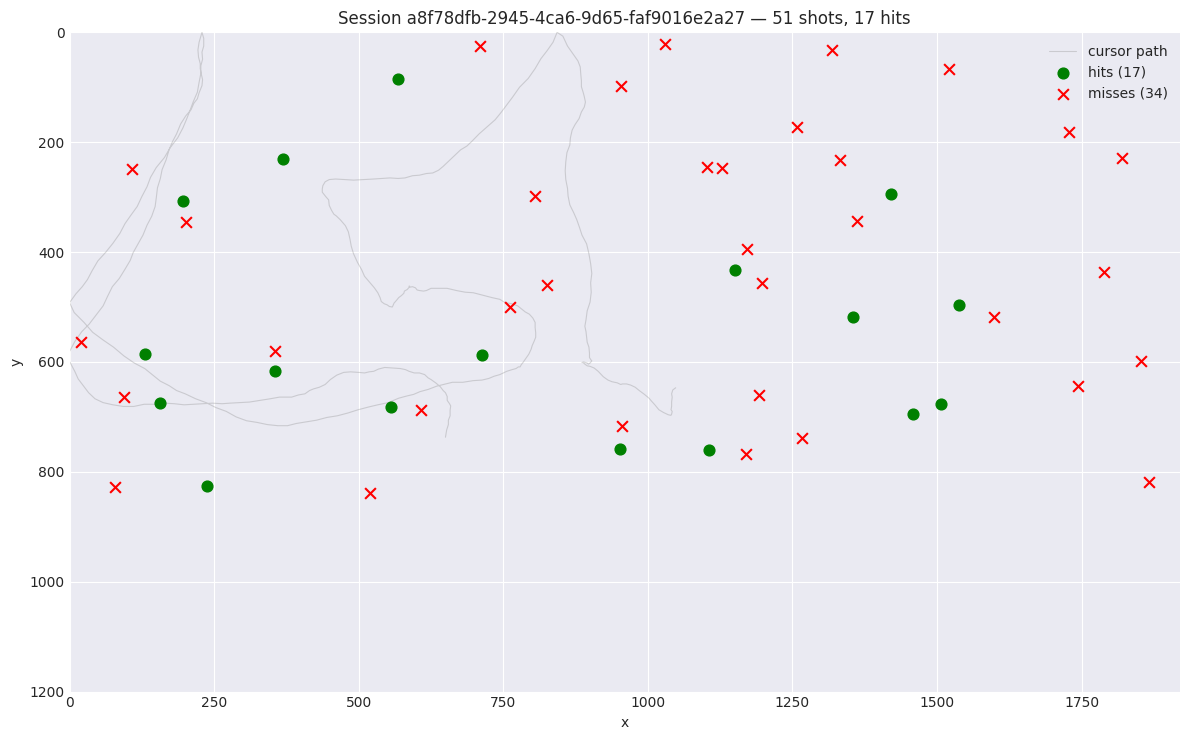

In [4]:
gun_df = q(f"""
SELECT timestamp, x, y
FROM isk.merged.gun_positions
WHERE sessionId='{last_session}'
ORDER BY timestamp
""")

shots_df = q(f"""
SELECT timestamp, state, x, y, duck_positions
FROM isk.merged.shots
WHERE sessionId='{last_session}'
ORDER BY timestamp
""")

hits = shots_df[shots_df['state'] == 'hit']
misses = shots_df[shots_df['state'] == 'missed']

fig, ax = plt.subplots(figsize=(12, 7.5))
ax.plot(gun_df['x'], gun_df['y'], color='gray', alpha=0.3, linewidth=0.8, label='cursor path')
ax.scatter(hits['x'], hits['y'], color='green', s=60, zorder=5, label=f'hits ({len(hits)})')
ax.scatter(misses['x'], misses['y'], color='red', marker='x', s=60, zorder=5, label=f'misses ({len(misses)})')
ax.set_xlim(0, 1920)
ax.set_ylim(1200, 0)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'Session {last_session} — {len(shots_df)} shots, {len(hits)} hits')
ax.legend()
plt.tight_layout()
plt.show()

## Population context

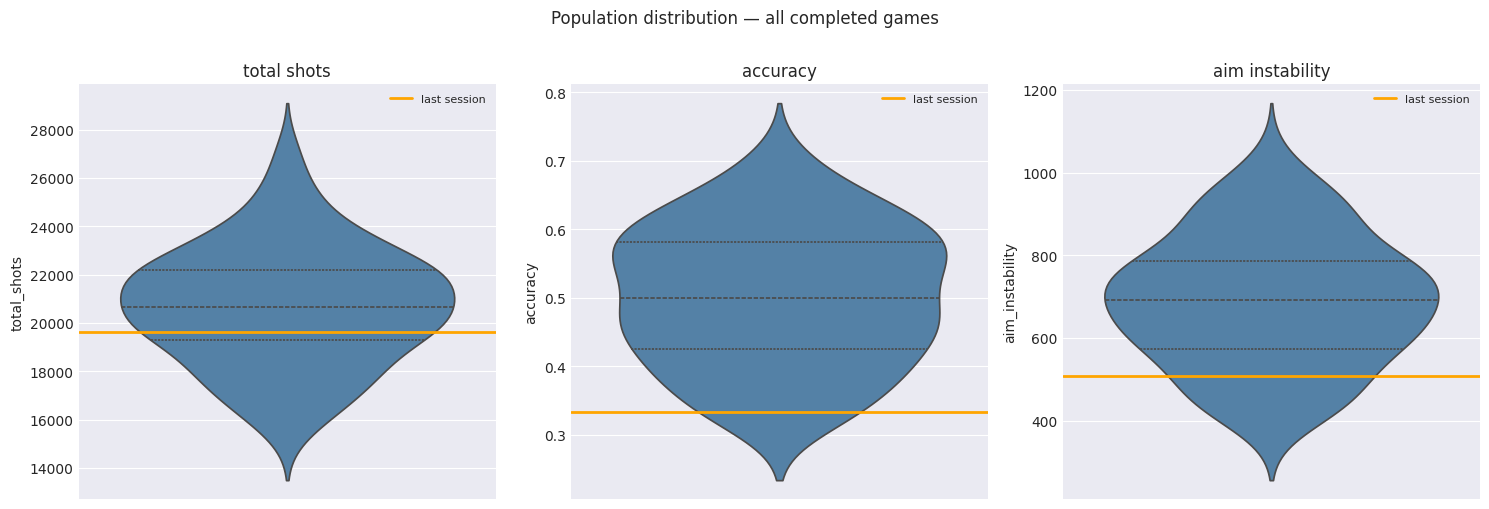

In [5]:
pop_df = q("""
SELECT
  s.sessionId,
  COUNT(*) AS total_shots,
  ROUND(AVG(CASE WHEN s.state='hit' THEN 1.0 ELSE 0.0 END), 3) AS accuracy,
  STDDEV(g.x) + STDDEV(g.y) AS aim_instability
FROM isk.merged.shots s
JOIN isk.merged.gun_positions g ON s.sessionId = g.sessionId
GROUP BY s.sessionId
""")

metrics = ['total_shots', 'accuracy', 'aim_instability']
last_row = pop_df[pop_df['sessionId'] == last_session]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric in zip(axes, metrics):
    sns.violinplot(y=pop_df[metric], ax=ax, color='steelblue', inner='quartile')
    if not last_row.empty:
        ax.axhline(last_row[metric].values[0], color='orange', linewidth=2, label='last session')
        ax.legend(fontsize=8)
    ax.set_title(metric.replace('_', ' '))
plt.suptitle('Population distribution — all completed games', y=1.01)
plt.tight_layout()
plt.show()

## Where the booth shoots — population heatmap

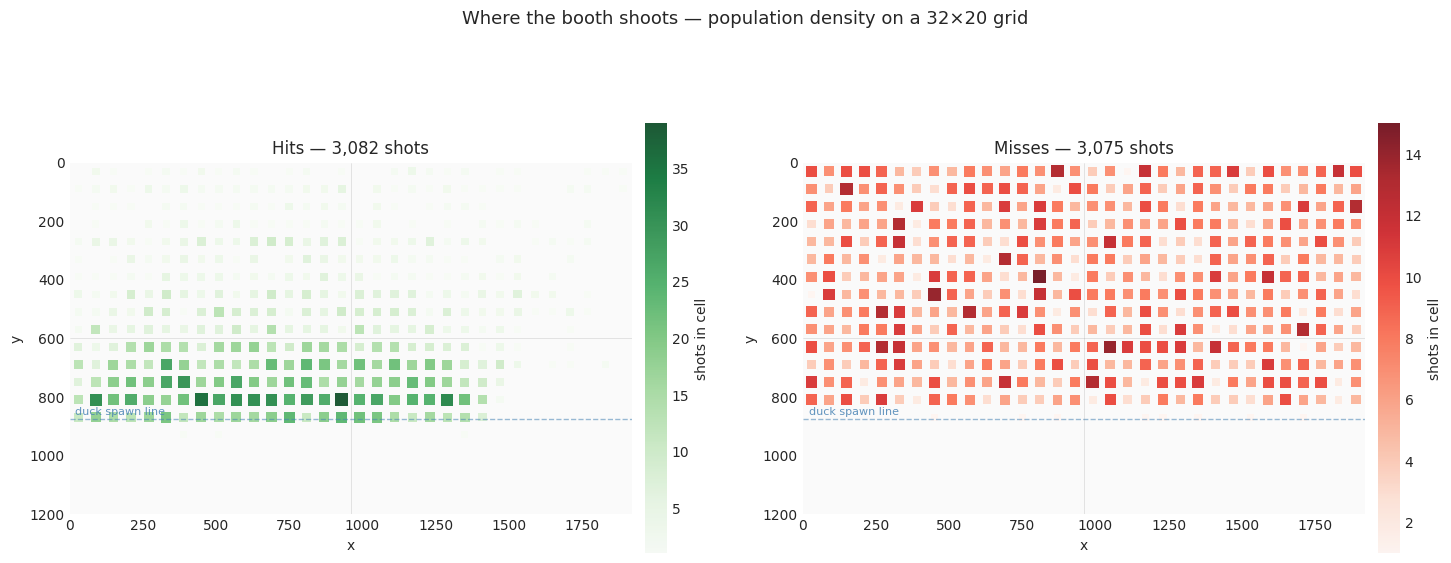

In [38]:
import numpy as np

all_shots = q("SELECT state, x, y FROM isk.merged.shots")

hits_all = all_shots[all_shots['state'] == 'hit']
misses_all = all_shots[all_shots['state'] == 'missed']

DUCK_SPAWN_Y = 875
XBINS, YBINS = 32, 20  # 60×60 px cells on a 1920×1200 screen

def grid_scatter(ax, df, cmap, title):
    hist, xedges, yedges = np.histogram2d(
        df['x'], df['y'],
        bins=[XBINS, YBINS],
        range=[[0, 1920], [0, 1200]],
    )
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    xx, yy = np.meshgrid(xc, yc, indexing='ij')

    flat_x = xx.flatten()
    flat_y = yy.flatten()
    flat_c = hist.flatten()
    mask = flat_c > 0

    if not mask.any():
        ax.set_title(title + ' — no data')
        return None

    sizes = flat_c[mask] / flat_c.max() * 60 + 25
    sc = ax.scatter(
        flat_x[mask], flat_y[mask],
        s=sizes,
        c=flat_c[mask],
        cmap=cmap,
        marker='s',
        alpha=0.88,
        edgecolors='none',
    )

    ax.axhline(DUCK_SPAWN_Y, color='steelblue', linewidth=1.0, linestyle='--', alpha=0.55)
    ax.text(20, DUCK_SPAWN_Y - 15, 'duck spawn line', color='steelblue', fontsize=8, alpha=0.85)
    ax.axvline(960, color='gray', linewidth=0.4, alpha=0.35)
    ax.axhline(600, color='gray', linewidth=0.4, alpha=0.35)
    ax.set_xlim(0, 1920)
    ax.set_ylim(1200, 0)
    ax.set_aspect('equal')
    ax.set_facecolor('#fafafa')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.18)
    return sc

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc1 = grid_scatter(axes[0], hits_all, 'Greens', f'Hits — {len(hits_all):,} shots')
sc2 = grid_scatter(axes[1], misses_all, 'Reds', f'Misses — {len(misses_all):,} shots')

if sc1 is not None:
    fig.colorbar(sc1, ax=axes[0], shrink=0.8, pad=0.02, label='shots in cell')
if sc2 is not None:
    fig.colorbar(sc2, ax=axes[1], shrink=0.8, pad=0.02, label='shots in cell')

plt.suptitle(
    'Where the booth shoots — population density on a 32×20 grid',
    y=1.02, fontsize=13,
)
plt.tight_layout()
plt.show()

## Booth leaderboard — top 10 scores today

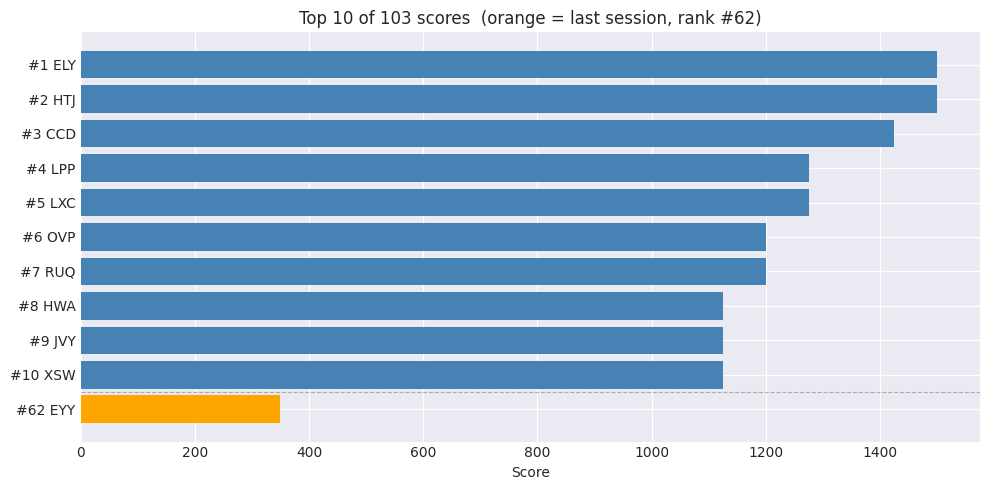

In [7]:
score_raw = q("SELECT sessionId, data FROM isk.merged.control_events WHERE event_type = 'score'")

score_rows = []
for _, row in score_raw.iterrows():
    parsed = json.loads(row['data'])
    parsed['sessionId'] = row['sessionId']
    score_rows.append(parsed)

scores_df = pd.DataFrame(score_rows)
scores_df['score'] = pd.to_numeric(scores_df['score'])
ranked = scores_df.sort_values('score', ascending=False).reset_index(drop=True)
ranked['rank'] = ranked.index + 1
total_players = len(ranked)

top10 = ranked.head(10).copy()

last_row = ranked[ranked['sessionId'] == last_session]
last_in_top10 = (not last_row.empty) and (last_row['rank'].iloc[0] <= 10)

if not last_row.empty and not last_in_top10:
    last_entry = last_row.copy()
    display_df = pd.concat([top10, last_entry], ignore_index=True)
else:
    display_df = top10

labels = [f"#{r['rank']} {r['name']}" for _, r in display_df.iterrows()]
colors = ['orange' if sid == last_session else 'steelblue' for sid in display_df['sessionId']]

fig, ax = plt.subplots(figsize=(10, max(5, 0.45 * len(display_df))))
ax.barh(labels, display_df['score'], color=colors)
ax.set_xlabel('Score')
title = f'Top 10 of {total_players} scores'
if not last_row.empty:
    title += f"  (orange = last session, rank #{int(last_row['rank'].iloc[0])})"
ax.set_title(title)
ax.invert_yaxis()

if not last_row.empty and not last_in_top10:
    sep_y = len(top10) - 0.5
    ax.axhline(sep_y, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## How games unfold — shot rate and hit rate by second-into-game

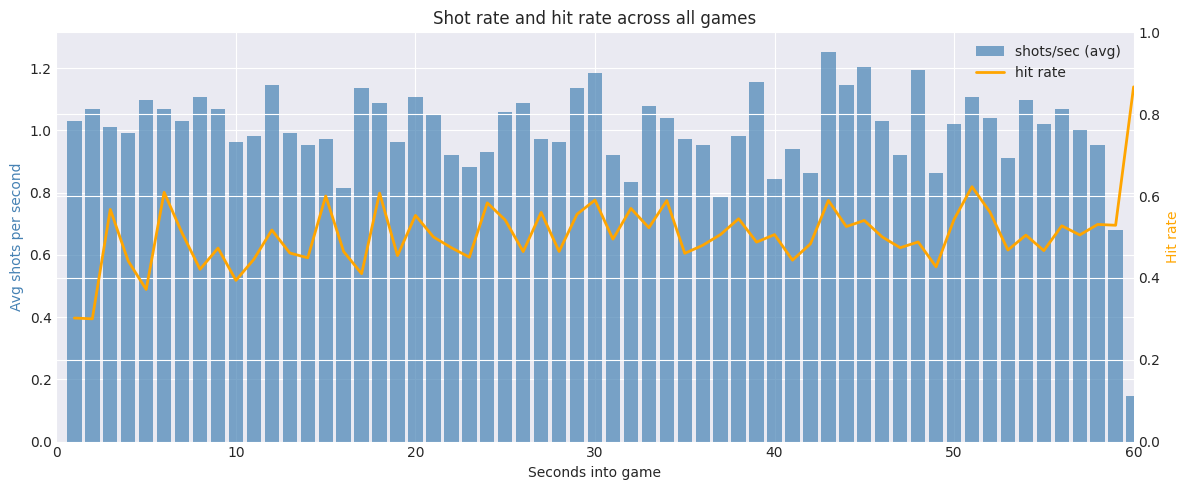

In [8]:
timeline_df = q("""
WITH starts AS (
  SELECT sessionId, MIN(timestamp) AS start_ts
  FROM isk.merged.control_events
  WHERE event_type = 'game_start'
  GROUP BY sessionId
)
SELECT
  CAST(FLOOR((s.timestamp - st.start_ts) / 1000.0) AS INT) AS sec,
  s.state
FROM isk.merged.shots s
JOIN starts st ON s.sessionId = st.sessionId
WHERE s.timestamp >= st.start_ts AND s.timestamp - st.start_ts < 70000
""")

n_sessions = q("SELECT COUNT(DISTINCT sessionId) AS n FROM isk.merged.control_events WHERE event_type = 'game_start'")['n'].iloc[0]

by_sec = timeline_df.groupby('sec').agg(
    total=('state', 'count'),
    hits=('state', lambda x: (x == 'hit').sum())
).reset_index()
by_sec = by_sec[by_sec['sec'] <= 60]
by_sec['shots_per_sec'] = by_sec['total'] / n_sessions
by_sec['hit_rate'] = by_sec['hits'] / by_sec['total']

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(by_sec['sec'], by_sec['shots_per_sec'], color='steelblue', alpha=0.7, label='shots/sec (avg)')
ax2.plot(by_sec['sec'], by_sec['hit_rate'], color='orange', linewidth=2, label='hit rate')

ax1.set_xlabel('Seconds into game')
ax1.set_ylabel('Avg shots per second', color='steelblue')
ax2.set_ylabel('Hit rate', color='orange')
ax1.set_xlim(0, 60)
ax2.set_ylim(0, 1)
ax1.set_title('Shot rate and hit rate across all games')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

## Score and accuracy — where you'd land

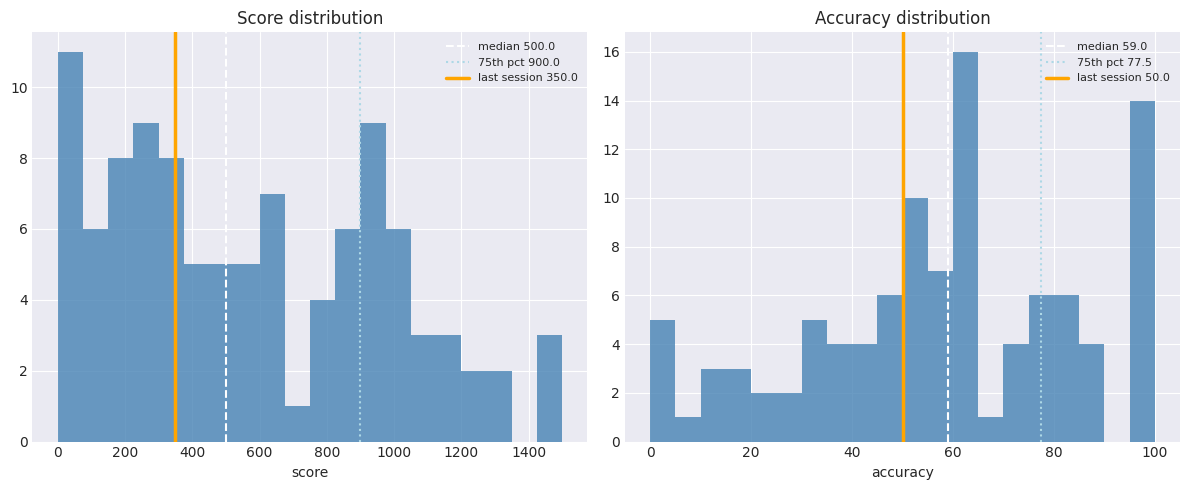

In [9]:
import numpy as np

score_raw = q("SELECT sessionId, data FROM isk.merged.control_events WHERE event_type = 'score'")
score_rows = []
for _, row in score_raw.iterrows():
    parsed = json.loads(row['data'])
    parsed['sessionId'] = row['sessionId']
    score_rows.append(parsed)
scores_df = pd.DataFrame(score_rows)
scores_df['score'] = pd.to_numeric(scores_df['score'])
scores_df['accuracy'] = pd.to_numeric(scores_df['accuracy'])

last_score_row = scores_df[scores_df['sessionId'] == last_session]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col in zip(axes, ['score', 'accuracy']):
    ax.hist(scores_df[col].dropna(), bins=20, color='steelblue', alpha=0.8)
    median_val = scores_df[col].median()
    p75_val = scores_df[col].quantile(0.75)
    ax.axvline(median_val, color='white', linestyle='--', linewidth=1.5, label=f'median {median_val:.1f}')
    ax.axvline(p75_val, color='lightblue', linestyle=':', linewidth=1.5, label=f'75th pct {p75_val:.1f}')
    if not last_score_row.empty:
        val = last_score_row[col].values[0]
        ax.axvline(val, color='orange', linewidth=2.5, label=f'last session {val:.1f}')
    ax.set_xlabel(col)
    ax.set_title(col.capitalize() + ' distribution')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Aim bias — do shooters lead, lag, or aim true?

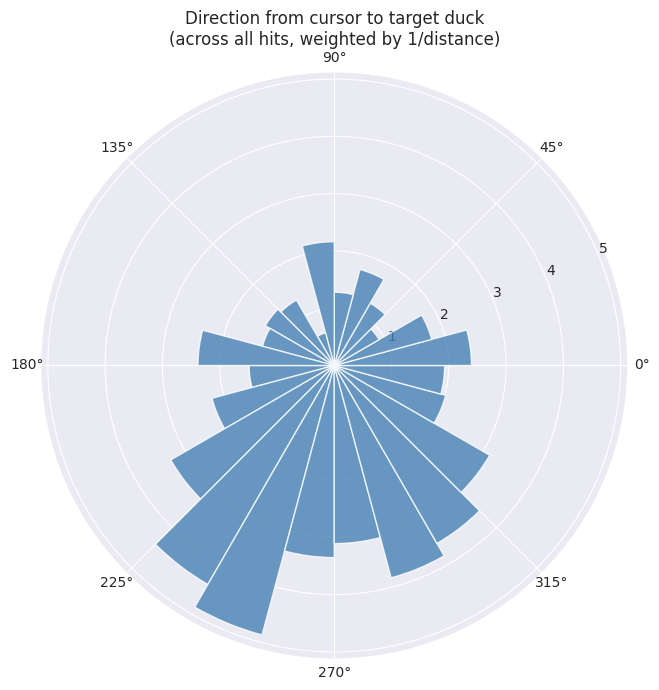

In [10]:
import numpy as np

all_shots_dp = q("""
SELECT sessionId, timestamp, state, x AS cursor_x, y AS cursor_y, duck_positions
FROM isk.merged.shots
ORDER BY sessionId, timestamp
""")

deltas = []
for session_id, grp in all_shots_dp.groupby('sessionId'):
    grp = grp.reset_index(drop=True)
    for i, row in grp.iterrows():
        if row['state'] != 'hit':
            continue
        if i == 0:
            continue
        prev_ducks = grp.loc[i - 1, 'duck_positions']
        if prev_ducks is None or (isinstance(prev_ducks, float) and np.isnan(prev_ducks)):
            continue
        if len(prev_ducks) == 0:
            continue
        cx, cy = row['cursor_x'], row['cursor_y']
        dists = [np.sqrt((d['x'] - cx) ** 2 + (d['y'] - cy) ** 2) for d in prev_ducks]
        nearest = prev_ducks[int(np.argmin(dists))]
        dx = nearest['x'] - cx
        dy = nearest['y'] - cy
        dist = np.sqrt(dx ** 2 + dy ** 2)
        if dist < 200:
            deltas.append((dx, dy, dist))

if deltas:
    dx_arr = np.array([d[0] for d in deltas])
    dy_arr = np.array([d[1] for d in deltas])
    dist_arr = np.array([d[2] for d in deltas])

    angles = np.arctan2(-dy_arr, dx_arr)
    weights = 1.0 / np.maximum(dist_arr, 1.0)

    n_bins = 24
    bin_edges = np.linspace(-np.pi, np.pi, n_bins + 1)
    counts, _ = np.histogram(angles, bins=bin_edges, weights=weights)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    width = 2 * np.pi / n_bins

    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
    ax.bar(bin_centers, counts, width=width, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.set_title('Direction from cursor to target duck\n(across all hits, weighted by 1/distance)', pad=20)
    plt.tight_layout()
    plt.show()
else:
    print("No valid hit deltas found — duck_positions may be empty or schema mismatch.")

## Shot anatomy — sunburst (state × quadrant × ducks on screen)

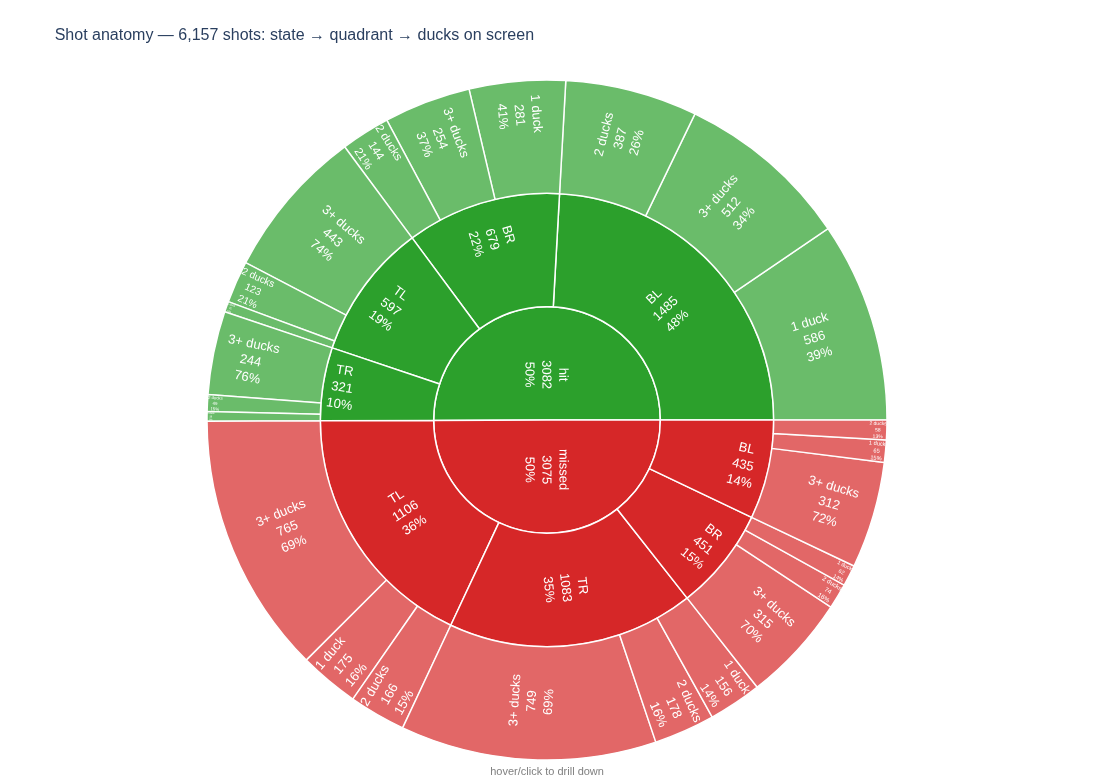

In [24]:
import plotly.express as px

df = q("""
SELECT state, x, y, cardinality(duck_positions) + CASE WHEN state='hit' THEN 1 ELSE 0 END AS ducks_on_screen
FROM isk.merged.shots
""")

if df.empty:
    print("No shot data available.")
else:
    def quadrant(x, y):
        return ('T' if y < 600 else 'B') + ('L' if x < 960 else 'R')

    df['quadrant'] = df.apply(lambda r: quadrant(r['x'], r['y']), axis=1)
    df['ducks_bucket'] = df['ducks_on_screen'].apply(lambda n: '1 duck' if n == 1 else ('2 ducks' if n == 2 else '3+ ducks'))

    fig = px.sunburst(
        df,
        path=['state', 'quadrant', 'ducks_bucket'],
        color='state',
        color_discrete_map={'hit': '#2ca02c', 'missed': '#d62728', '(?)': '#888'},
        title=f'Shot anatomy — {len(df):,} shots: state → quadrant → ducks on screen',
    )
    fig.update_traces(
        textinfo='label+value+percent parent',
        insidetextorientation='radial',
        textfont_size=13,
        marker_line_color='white',
        marker_line_width=1.5,
        hovertemplate='<b>%{label}</b><br>shots: %{value}<br>%{percentParent} of parent<br>%{percentRoot} of total<extra></extra>',
    )
    fig.update_layout(
        height=780,
        width=900,
        margin=dict(t=80, l=20, r=20, b=20),
        title_font_size=16,
        annotations=[dict(
            text='hover/click to drill down<br>green = hits · red = misses',
            x=0.5, y=-0.05, xref='paper', yref='paper',
            showarrow=False, font=dict(size=11, color='gray'),
        )],
    )
    fig.show()

## Player corpus — accuracy vs score

(With real booth data — where individual visitors typically play several times — a treemap of `name → games → score` becomes the natural visual. With synthetic data each random name plays once, so we use a per-game scatter instead.)

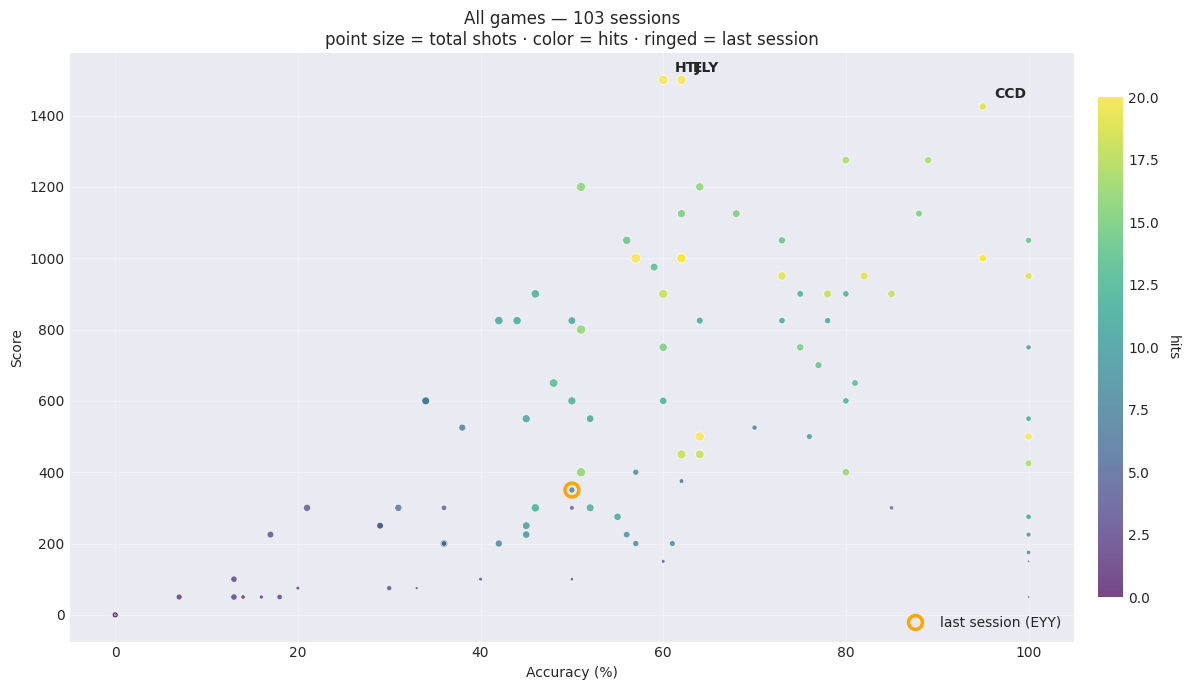

In [30]:
score_raw = q("SELECT sessionId, data FROM isk.merged.control_events WHERE event_type = 'score'")

if score_raw.empty:
    print("No score events available.")
else:
    score_rows = []
    for _, row in score_raw.iterrows():
        try:
            parsed = json.loads(row['data'])
            parsed['sessionId'] = row['sessionId']
            score_rows.append(parsed)
        except Exception:
            pass

    games_df = pd.DataFrame(score_rows)
    for col in ['score', 'accuracy', 'shots', 'hits']:
        games_df[col] = pd.to_numeric(games_df[col], errors='coerce')
    games_df = games_df.dropna(subset=['score', 'accuracy', 'shots', 'name'])

    fig, ax = plt.subplots(figsize=(13, 7))
    sc = ax.scatter(
        games_df['accuracy'], games_df['score'],
        s=games_df['shots'] * 1.4,
        c=games_df['hits'],
        cmap='viridis',
        alpha=0.7, edgecolors='white', linewidths=0.6,
    )

    top3 = games_df.nlargest(3, 'score')
    for _, row in top3.iterrows():
        ax.annotate(
            row['name'], (row['accuracy'], row['score']),
            textcoords='offset points', xytext=(8, 6),
            fontsize=10, fontweight='bold',
        )

    last_row = games_df[games_df['sessionId'] == last_session]
    if not last_row.empty:
        ax.scatter(
            last_row['accuracy'], last_row['score'],
            s=last_row['shots'].iloc[0] * 1.4 + 80,
            facecolors='none', edgecolors='orange', linewidths=2.5,
            label=f"last session ({last_row['name'].iloc[0]})",
        )
        ax.legend(loc='lower right', fontsize=10)

    cbar = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label('hits', rotation=270, labelpad=15)

    ax.set_xlabel('Accuracy (%)')
    ax.set_ylabel('Score')
    ax.set_title(
        f'All games — {len(games_df):,} sessions\n'
        'point size = total shots · color = hits · ringed = last session',
        fontsize=12,
    )
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Last session anatomy — icicle (game phase → state → cursor zone)

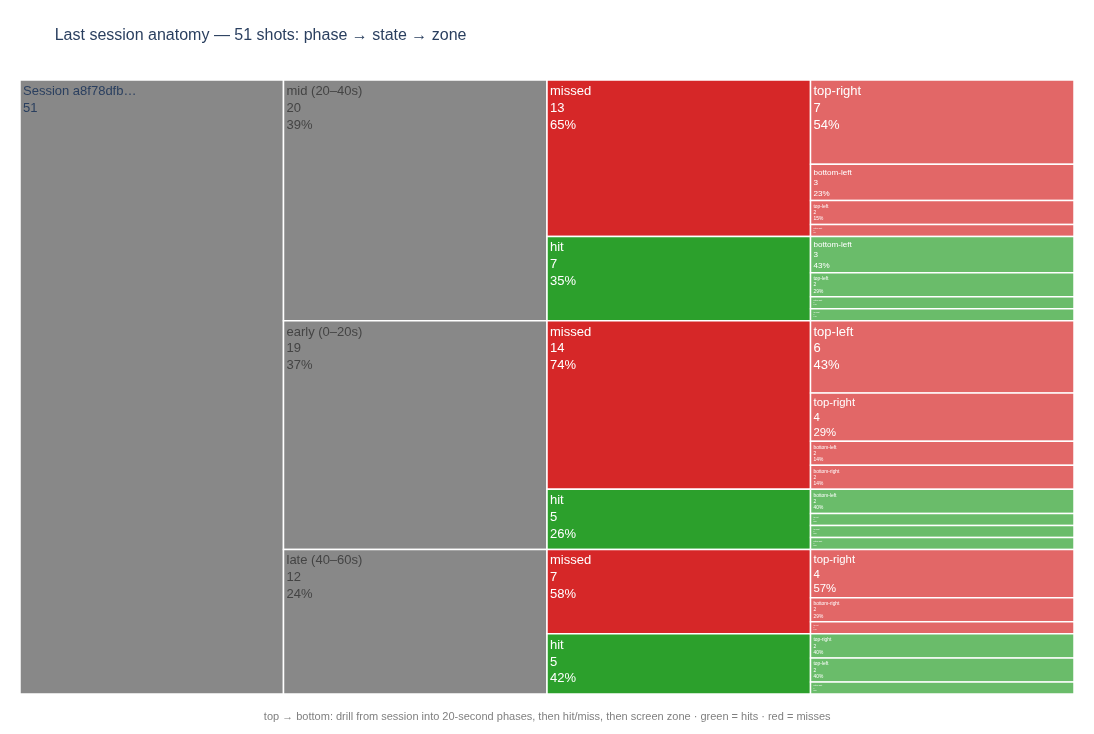

In [26]:
import plotly.express as px

shots_last = q(f"""
SELECT timestamp, state, x, y
FROM isk.merged.shots
WHERE sessionId = '{last_session}'
ORDER BY timestamp
""")

if shots_last.empty:
    print(f"Session {last_session[:8]}… has no shots.")
else:
    start_row = q(f"""
SELECT MIN(timestamp) AS start_ts
FROM isk.merged.control_events
WHERE sessionId = '{last_session}' AND event_type = 'game_start'
""")
    game_start = start_row['start_ts'].iloc[0] if not start_row.empty else shots_last['timestamp'].min()

    def phase(t):
        e = (t - game_start) / 1000.0
        return 'early (0–20s)' if e < 20 else 'mid (20–40s)' if e < 40 else 'late (40–60s)'

    def zone(x, y):
        return ('top' if y < 600 else 'bottom') + '-' + ('left' if x < 960 else 'right')

    shots_last['phase'] = shots_last['timestamp'].apply(phase)
    shots_last['zone'] = shots_last.apply(lambda r: zone(r['x'], r['y']), axis=1)

    fig = px.icicle(
        shots_last,
        path=[px.Constant(f"Session {last_session[:8]}…"), 'phase', 'state', 'zone'],
        color='state',
        color_discrete_map={'hit': '#2ca02c', 'missed': '#d62728', '(?)': '#888'},
        title=f"Last session anatomy — {len(shots_last)} shots: phase → state → zone",
    )
    fig.update_traces(
        textinfo='label+value+percent parent',
        textfont_size=13,
        marker_line_color='white',
        marker_line_width=1.5,
    )
    fig.update_layout(
        height=720,
        width=1100,
        margin=dict(t=80, l=20, r=20, b=40),
        title_font_size=16,
        annotations=[dict(
            text='top → bottom: drill from session into 20-second phases, then hit/miss, then screen zone · green = hits · red = misses',
            x=0.5, y=-0.05, xref='paper', yref='paper',
            showarrow=False, font=dict(size=11, color='gray'),
        )],
    )
    fig.show()

## Pacing — inter-shot interval distribution

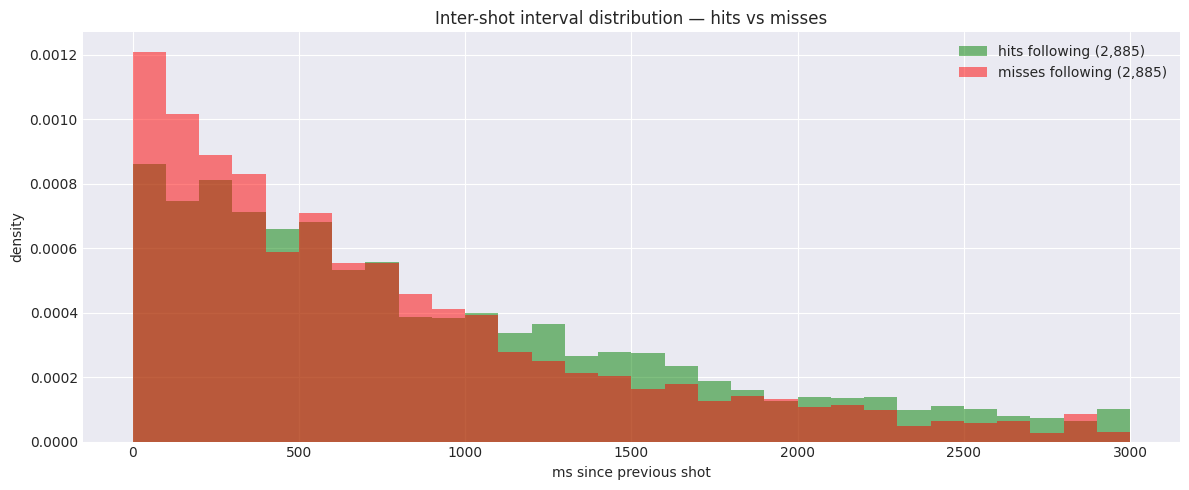

In [14]:
all_shots_pacing = q("""
SELECT sessionId, timestamp, state
FROM isk.merged.shots
ORDER BY sessionId, timestamp
""")

hit_deltas = []
miss_deltas = []

for _, grp in all_shots_pacing.groupby('sessionId'):
    grp = grp.reset_index(drop=True)
    for i in range(1, len(grp)):
        delta = grp.loc[i, 'timestamp'] - grp.loc[i - 1, 'timestamp']
        if 0 < delta <= 3000:
            if grp.loc[i, 'state'] == 'hit':
                hit_deltas.append(delta)
            else:
                miss_deltas.append(delta)

if not hit_deltas and not miss_deltas:
    print("Not enough shot data to compute inter-shot intervals.")
else:
    fig, ax = plt.subplots(figsize=(12, 5))
    bins = range(0, 3001, 100)
    ax.hist(hit_deltas, bins=bins, density=True, alpha=0.5, color='green', label=f'hits following ({len(hit_deltas):,})')
    ax.hist(miss_deltas, bins=bins, density=True, alpha=0.5, color='red', label=f'misses following ({len(miss_deltas):,})')
    ax.set_xlabel('ms since previous shot')
    ax.set_ylabel('density')
    ax.set_title('Inter-shot interval distribution — hits vs misses')
    ax.legend()
    plt.tight_layout()
    plt.show()


## Cursor attention — where the cursor lives across all games

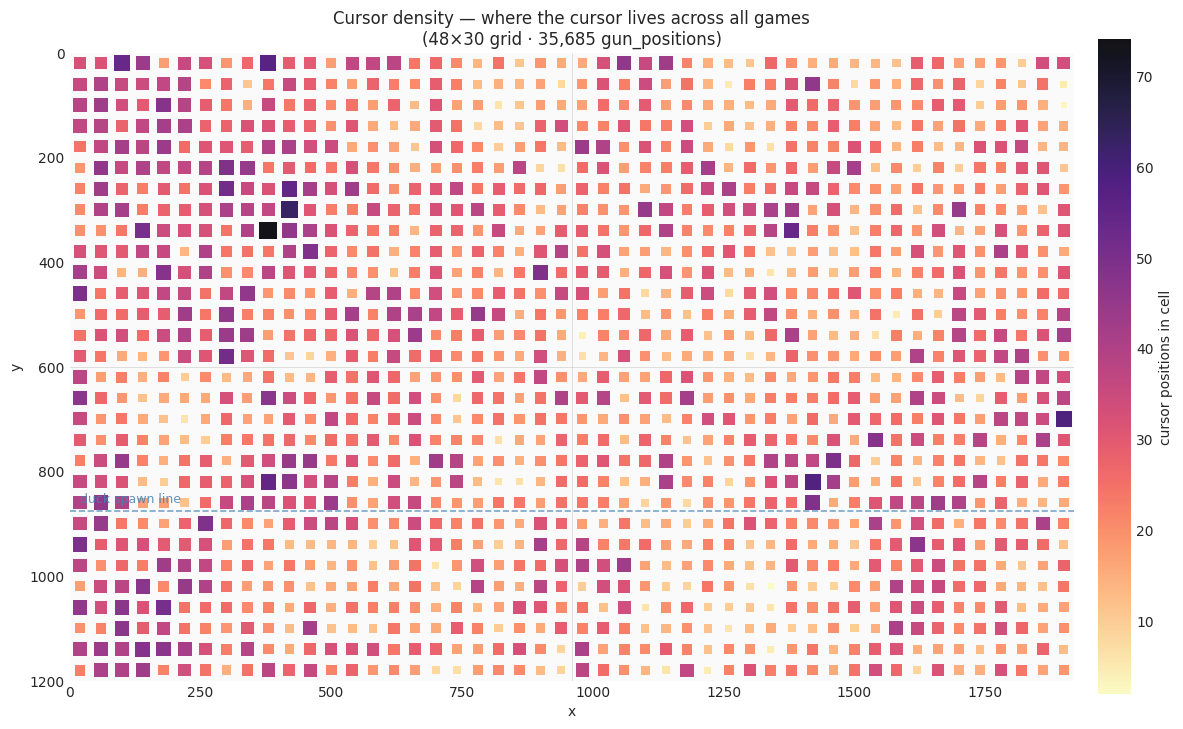

In [41]:
import numpy as np

cursor_df = q("SELECT x, y FROM isk.merged.gun_positions LIMIT 100000")

if cursor_df.empty:
    print("No gun_positions data available.")
else:
    DUCK_SPAWN_Y = 875
    XBINS, YBINS = 48, 30

    hist, xedges, yedges = np.histogram2d(
        cursor_df['x'], cursor_df['y'],
        bins=[XBINS, YBINS],
        range=[[0, 1920], [0, 1200]],
    )
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    xx, yy = np.meshgrid(xc, yc, indexing='ij')
    flat_x = xx.flatten()
    flat_y = yy.flatten()
    flat_c = hist.flatten()
    mask = flat_c > 0

    sizes = flat_c[mask] / flat_c.max() * 150 + 15

    fig, ax = plt.subplots(figsize=(13, 8))
    ax.set_facecolor('#fafafa')
    sc = ax.scatter(
        flat_x[mask], flat_y[mask],
        s=sizes,
        c=flat_c[mask],
        cmap='magma_r',
        marker='s',
        alpha=0.92,
        edgecolors='none',
    )

    ax.axhline(DUCK_SPAWN_Y, color='steelblue', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.text(20, DUCK_SPAWN_Y - 15, 'duck spawn line', color='steelblue', fontsize=9, alpha=0.85)
    ax.axvline(960, color='gray', linewidth=0.4, alpha=0.4)
    ax.axhline(600, color='gray', linewidth=0.4, alpha=0.4)

    ax.set_xlim(0, 1920)
    ax.set_ylim(1200, 0)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.18)
    ax.set_title(
        f'Cursor density — where the cursor lives across all games\n'
        f'({XBINS}×{YBINS} grid · {len(cursor_df):,} gun_positions)',
        fontsize=12,
    )
    fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02, label='cursor positions in cell')
    plt.tight_layout()
    plt.show()

## Hot streaks — longest consecutive-hit streak per session

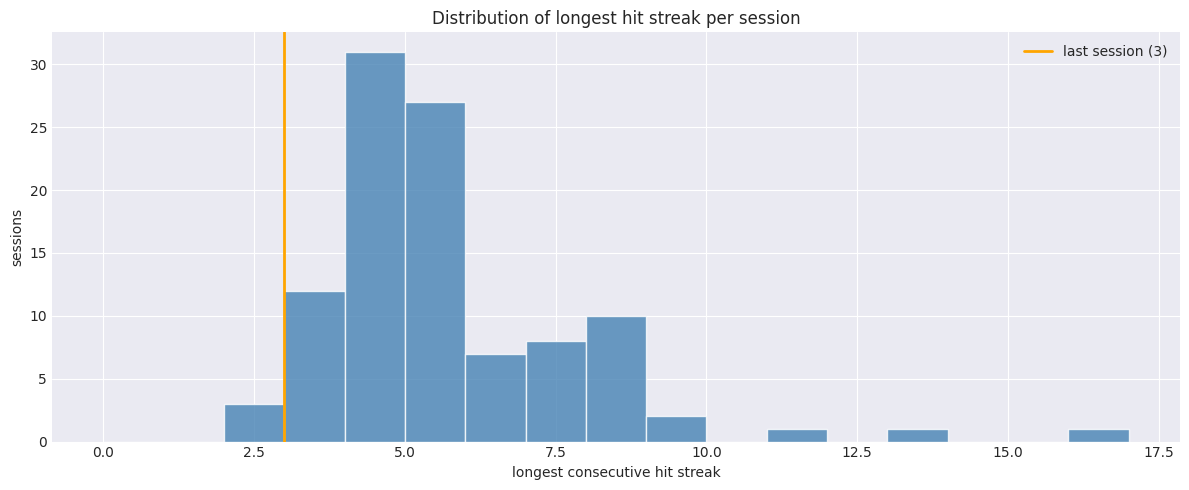

In [16]:
streak_shots = q("SELECT sessionId, timestamp, state FROM isk.merged.shots ORDER BY sessionId, timestamp")

if streak_shots.empty:
    print("No shot data available.")
else:
    def longest_streak(states):
        best = cur = 0
        for s in states:
            cur = cur + 1 if s == 'hit' else 0
            best = max(best, cur)
        return best

    streaks = (
        streak_shots.groupby('sessionId')['state']
        .apply(longest_streak)
        .reset_index()
    )
    streaks.columns = ['sessionId', 'longest_streak']

    last_streak = streaks[streaks['sessionId'] == last_session]['longest_streak']
    max_streak = int(streaks['longest_streak'].max())

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(streaks['longest_streak'], bins=range(0, max_streak + 2), color='steelblue', alpha=0.8, edgecolor='white')
    if not last_streak.empty:
        ax.axvline(last_streak.iloc[0], color='orange', linewidth=2, label=f'last session ({int(last_streak.iloc[0])})')
        ax.legend()
    ax.set_xlabel('longest consecutive hit streak')
    ax.set_ylabel('sessions')
    ax.set_title('Distribution of longest hit streak per session')
    plt.tight_layout()
    plt.show()


## Reaction — time from game_start to first shot

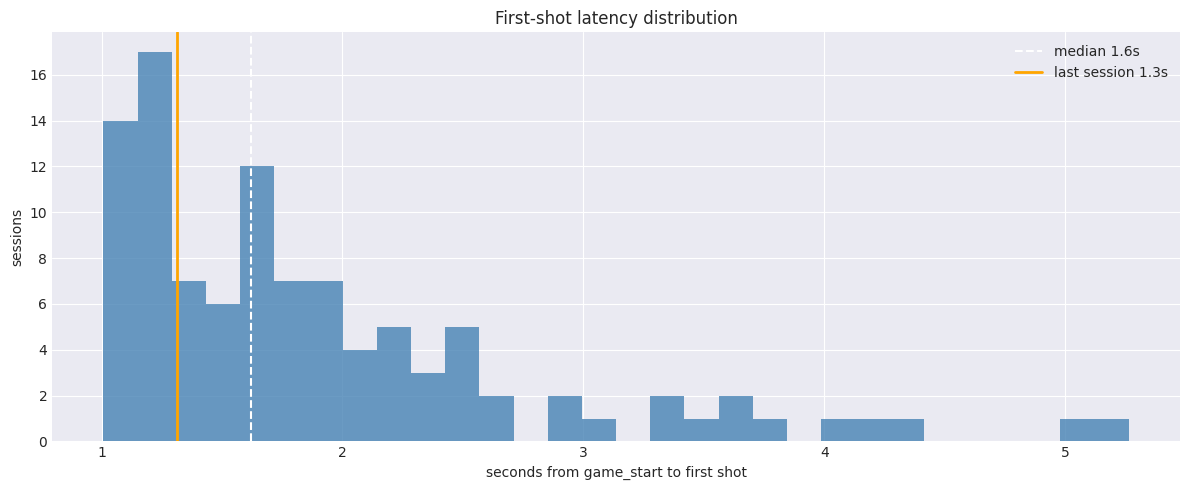

In [17]:
import numpy as np

latency_df = q("""
WITH starts AS (
  SELECT sessionId, MIN(timestamp) AS start_ts
  FROM isk.merged.control_events
  WHERE event_type = 'game_start'
  GROUP BY sessionId
),
first_shots AS (
  SELECT sessionId, MIN(timestamp) AS first_shot_ts
  FROM isk.merged.shots
  GROUP BY sessionId
)
SELECT fs.sessionId, (fs.first_shot_ts - st.start_ts) / 1000.0 AS latency_s
FROM first_shots fs
JOIN starts st ON fs.sessionId = st.sessionId
WHERE (fs.first_shot_ts - st.start_ts) BETWEEN 0 AND 30000
""")

if latency_df.empty:
    print("Not enough data to compute first-shot latency.")
else:
    last_lat = latency_df[latency_df['sessionId'] == last_session]['latency_s']
    median_lat = latency_df['latency_s'].median()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(latency_df['latency_s'], bins=30, color='steelblue', alpha=0.8)
    ax.axvline(median_lat, color='white', linestyle='--', linewidth=1.5, label=f'median {median_lat:.1f}s')
    if not last_lat.empty:
        ax.axvline(last_lat.iloc[0], color='orange', linewidth=2, label=f'last session {last_lat.iloc[0]:.1f}s')
    ax.set_xlabel('seconds from game_start to first shot')
    ax.set_ylabel('sessions')
    ax.set_title('First-shot latency distribution')
    ax.legend()
    plt.tight_layout()
    plt.show()


## Scoring pace — population fan chart with last session overlay

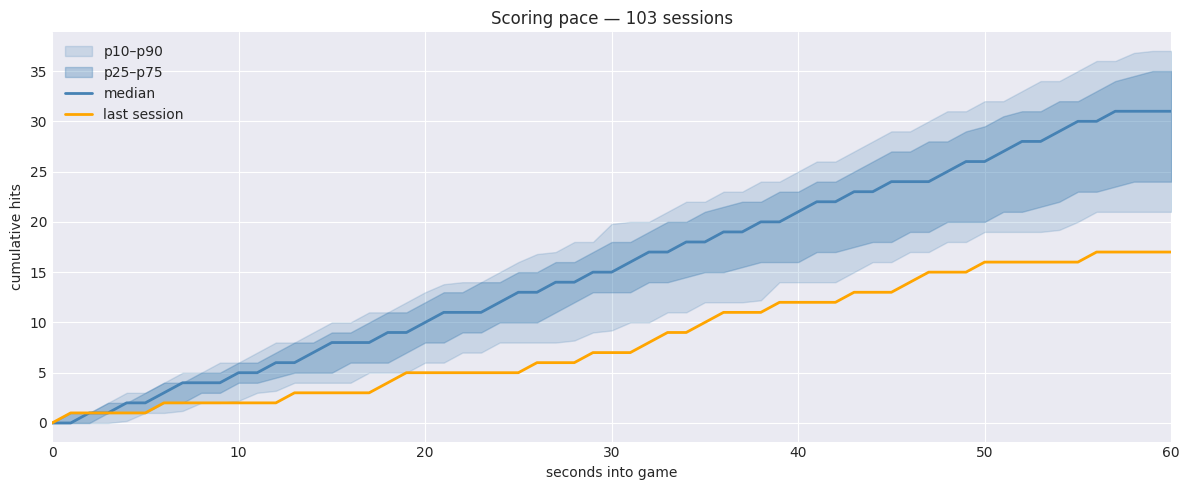

In [18]:
import numpy as np

fan_df = q("""
WITH starts AS (
  SELECT sessionId, MIN(timestamp) AS start_ts
  FROM isk.merged.control_events
  WHERE event_type = 'game_start'
  GROUP BY sessionId
)
SELECT s.sessionId, CAST(FLOOR((s.timestamp - st.start_ts) / 1000.0) AS INT) AS sec, s.state
FROM isk.merged.shots s
JOIN starts st ON s.sessionId = st.sessionId
WHERE s.timestamp >= st.start_ts AND s.timestamp - st.start_ts <= 60000
""")

if fan_df.empty:
    print("Not enough shot data for fan chart.")
else:
    seconds = range(0, 61)
    session_cum = {}
    for sid, grp in fan_df.groupby('sessionId'):
        grp = grp.sort_values('sec')
        cum = 0
        by_sec = {}
        for s in seconds:
            hits_at = (grp[(grp['sec'] == s) & (grp['state'] == 'hit')].shape[0])
            cum += hits_at
            by_sec[s] = cum
        session_cum[sid] = by_sec

    cum_matrix = np.array([[session_cum[sid][s] for s in seconds] for sid in session_cum])

    p25 = np.percentile(cum_matrix, 25, axis=0)
    p50 = np.percentile(cum_matrix, 50, axis=0)
    p75 = np.percentile(cum_matrix, 75, axis=0)
    p90 = np.percentile(cum_matrix, 90, axis=0)
    p10 = np.percentile(cum_matrix, 10, axis=0)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.fill_between(seconds, p10, p90, alpha=0.2, color='steelblue', label='p10–p90')
    ax.fill_between(seconds, p25, p75, alpha=0.35, color='steelblue', label='p25–p75')
    ax.plot(seconds, p50, color='steelblue', linewidth=2, label='median')

    if last_session in session_cum:
        last_cum = [session_cum[last_session][s] for s in seconds]
        ax.plot(seconds, last_cum, color='orange', linewidth=2, label='last session')

    ax.set_xlabel('seconds into game')
    ax.set_ylabel('cumulative hits')
    ax.set_title(f'Scoring pace — {len(session_cum)} sessions')
    ax.set_xlim(0, 60)
    ax.legend()
    plt.tight_layout()
    plt.show()


## Where shots land best — accuracy by screen quadrant

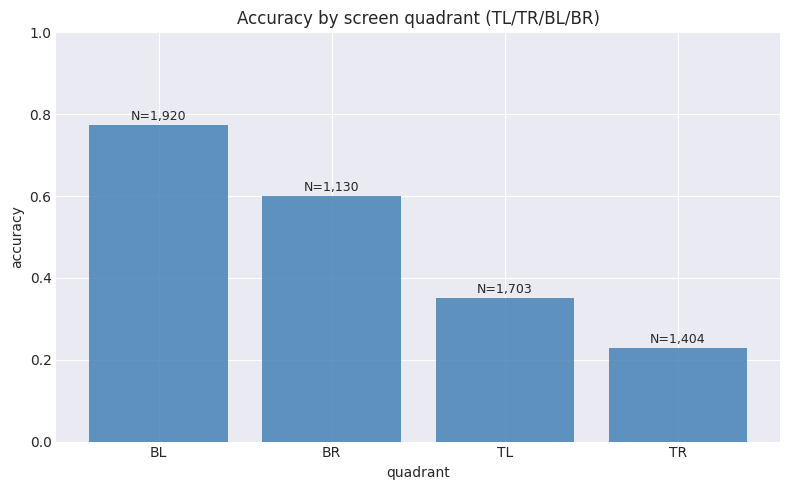

In [19]:
quad_shots = q("SELECT state, x, y FROM isk.merged.shots")

if quad_shots.empty:
    print("No shot data available.")
else:
    quad_shots['quadrant'] = quad_shots.apply(
        lambda r: ('T' if r['y'] < 600 else 'B') + ('L' if r['x'] < 960 else 'R'),
        axis=1,
    )
    quad_agg = quad_shots.groupby('quadrant').agg(
        total=('state', 'count'),
        hits=('state', lambda x: (x == 'hit').sum()),
    ).reset_index()
    quad_agg['accuracy'] = quad_agg['hits'] / quad_agg['total']

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(quad_agg['quadrant'], quad_agg['accuracy'], color='steelblue', alpha=0.85)
    for bar, (_, row) in zip(bars, quad_agg.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'N={row["total"]:,}',
            ha='center', va='bottom', fontsize=9,
        )
    ax.set_ylim(0, 1)
    ax.set_xlabel('quadrant')
    ax.set_ylabel('accuracy')
    ax.set_title('Accuracy by screen quadrant (TL/TR/BL/BR)')
    plt.tight_layout()
    plt.show()


## Spurious correlation — does your first initial predict your accuracy?

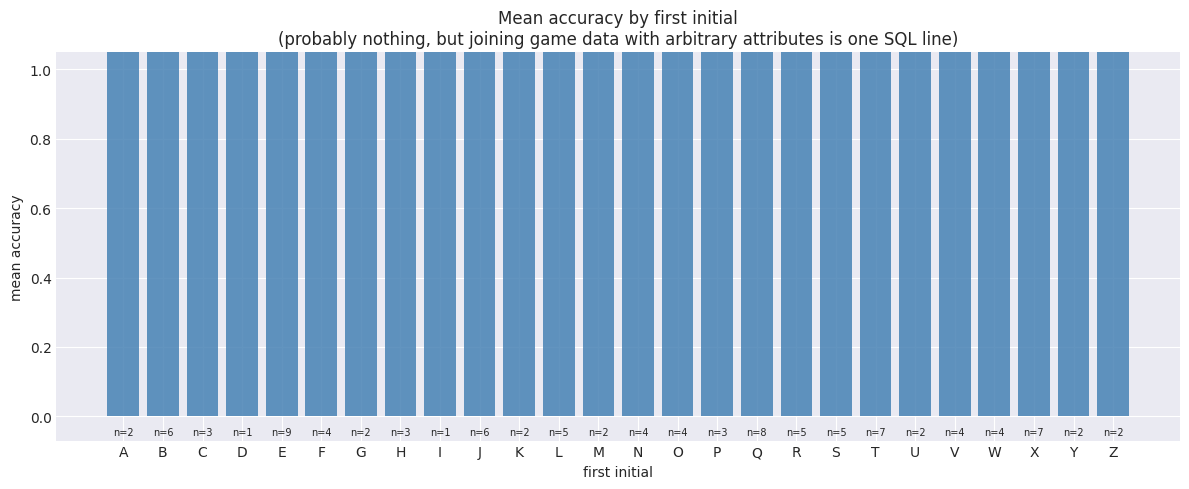

In [20]:
import numpy as np

sc_raw = q("SELECT sessionId, data FROM isk.merged.control_events WHERE event_type = 'score'")

if sc_raw.empty:
    print("No score events available.")
else:
    sc_rows = []
    for _, row in sc_raw.iterrows():
        try:
            parsed = json.loads(row['data'])
            sc_rows.append({'name': parsed.get('name', ''), 'accuracy': float(parsed.get('accuracy', 0))})
        except Exception:
            pass

    sc_df = pd.DataFrame(sc_rows)
    sc_df = sc_df[sc_df['name'].str.len() > 0].copy()
    sc_df['initial'] = sc_df['name'].str[0].str.upper()
    sc_df = sc_df[sc_df['initial'].str.isalpha()]

    by_letter = sc_df.groupby('initial').agg(
        mean_acc=('accuracy', 'mean'),
        n=('accuracy', 'count'),
        stderr=('accuracy', lambda x: x.std() / np.sqrt(len(x)) if len(x) > 1 else 0),
    ).reset_index().sort_values('initial')

    if by_letter.empty:
        print("Not enough named player data.")
    else:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.bar(by_letter['initial'], by_letter['mean_acc'],
               yerr=by_letter['stderr'], color='steelblue', alpha=0.85,
               error_kw={'elinewidth': 1.2, 'capsize': 3})
        for _, row in by_letter.iterrows():
            ax.text(row['initial'], -0.03, f'n={int(row["n"])}', ha='center', va='top', fontsize=7)
        ax.set_ylim(-0.07, 1.05)
        ax.set_xlabel('first initial')
        ax.set_ylabel('mean accuracy')
        ax.set_title('Mean accuracy by first initial\n(probably nothing, but joining game data with arbitrary attributes is one SQL line)')
        plt.tight_layout()
        plt.show()


## Conversation Kit — Prepared Props

Runnable cells the salesperson can show during conversations. Each demonstrates a specific Streambased capability that is hard or impossible in alternative architectures.

### Add a new metric retroactively, no infra changes

Imagine an analyst wants 'difficulty-adjusted accuracy' — accuracy weighted by how many ducks were on screen. In a Flink-pre-agg world this is a job change + replay across the retention window. Here it's 4 lines of SQL covering both fresh and historical events.

In [27]:
q("""
SELECT
  ROUND(AVG(CASE WHEN state='hit' THEN 1.0 ELSE 0.0 END), 3) AS raw_accuracy,
  ROUND(AVG((CASE WHEN state='hit' THEN 1.0 ELSE 0.0 END) * (cardinality(duck_positions) + CASE WHEN state='hit' THEN 1 ELSE 0 END)), 3) AS difficulty_weighted_accuracy
FROM isk.merged.shots
""")

,raw_accuracy,difficulty_weighted_accuracy
0,0.501,1.359


### Ask a question nobody pre-aggregated

Accuracy as a function of how many ducks were on screen. Nobody set up a Flink job for this — the raw events are queryable across hot+cold.

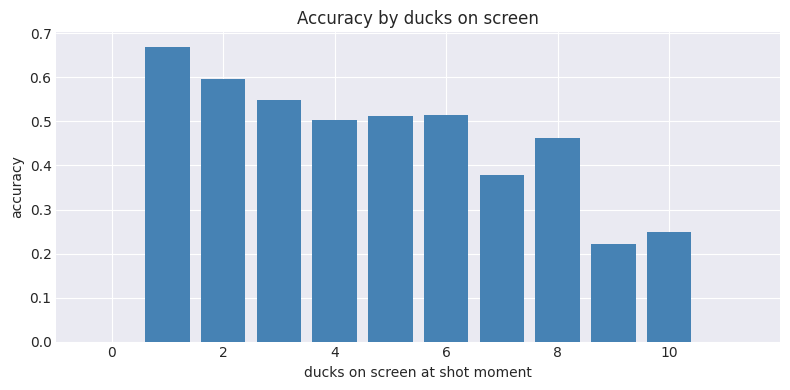

In [28]:
ducks_df = q("""
SELECT
  cardinality(duck_positions) + CASE WHEN state='hit' THEN 1 ELSE 0 END AS ducks_on_screen,
  COUNT(*) AS shots,
  ROUND(AVG(CASE WHEN state='hit' THEN 1.0 ELSE 0.0 END), 3) AS accuracy
FROM isk.merged.shots
GROUP BY 1
ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(ducks_df['ducks_on_screen'], ducks_df['accuracy'], color='steelblue')
ax.set_xlabel('ducks on screen at shot moment')
ax.set_ylabel('accuracy')
ax.set_title('Accuracy by ducks on screen')
plt.tight_layout()
plt.show()

### Hot vs cold semantics — same data, three views

**hotset** = Kafka topic, zero commit interval, real-time. **coldset** = compacted Iceberg snapshots on MinIO. **merged** = unified virtual view — one query, both tiers.

In [21]:
tiers = [
    ('isk.hotset.shots',    'SELECT COUNT(*) AS cnt FROM isk.hotset.shots'),
    ('direct.coldset.shots','SELECT COUNT(*) AS cnt FROM direct.coldset.shots'),
    ('isk.merged.shots',   'SELECT COUNT(*) AS cnt FROM isk.merged.shots'),
]

rows = []
for label, sql in tiers:
    cnt = spark.sql(sql).collect()[0]['cnt']
    rows.append({'table': label, 'row_count': cnt})

pd.DataFrame(rows)

26/04/30 16:32:18 WARN AuthManagers: The property rest.sigv4-enabled is deprecated and will be removed in a future release. Please use the property rest.auth.type=sigv4 instead.


,table,row_count
0,isk.hotset.shots,166
1,direct.coldset.shots,5991
2,isk.merged.shots,6157


## Objection cheat sheet

Pre-prepared 'yes, but…' counters for common pushback. Each card is a complete narrative beat for the salesperson.

### Card: "I can do this with Flink"

*Yes, but Flink is a continuous-transform engine.* To get analytical SQL out of it: define a job → emit aggregates to a sink → query the sink with another tool → redeploy + replay every time the question changes. Streambased lets you ask the question in SQL after the data has happened.

**Proof above:** the "new metric retroactively" cell — 4 lines of SQL across full retention. In Flink that's a job change + backfill window.

### Card: "I'll pre-aggregate in Flink and sink to Iceberg"

*Yes, but pre-agg locks you in.* Bug in your windowing function = replay from retention forward. New aggregation = new Flink job, new sink table. Schema evolution = coordinated change across job + sink + readers. The pre-agg locks you into the questions you thought of in advance.

With Streambased: hotset is unconditionally raw. Pre-agg, when you want it, is a *batch SQL job* against coldset, not a streaming pipeline.

*Honest concession:* if you pre-agg coldset, "live + history" of a pre-agg becomes `UNION(live agg over hotset, pre-agg snapshot from coldset)` — a SQL pattern, not a new pipeline, but not the seamless single-table experience.

### Card: "Flink does sub-second windowed aggs — you can't"

*Yes — and we don't claim to.* Flink for continuous low-latency transforms with exactly-once side-effects. Streambased for ad-hoc analytical SQL on the same Kafka data. Often complementary. If your workload is a known materialization, keep using Flink. If your workload is questions you haven't thought of yet, that's us.

### Card: "Our data platform team owns Flink, they handle this"

*Yes — and that's exactly the bottleneck.* New question = ticket → backlog → weeks. Flink requires cluster, expertise, headroom, and upstream coordination. Most analysts/data scientists/BI users don't have any of that.

Streambased puts fresh Kafka data in front of *anyone who writes SQL* via the standard Iceberg ecosystem — Snowflake federation, Spark, DuckDB, BI tools. The platform team stops being the bottleneck for analytical questions, and stays in the loop for the things that genuinely need streaming infra (alerting, exactly-once, sub-second aggs).

### Card: "I'll use Tableflow / Snowpipe / an Iceberg sink connector"

*Yes — these can hit low-single-digit-second freshness end-to-end.* Don't lead with the freshness number; the gap is real but smaller than you might think. The actual differentiation is structural:

- **Tableflow** pays for low-latency commits with continuous compaction rewrites — frequent commits = many small files = ongoing rewrite work. And it's a **Confluent product** — locks freshness to Confluent Cloud / Confluent Platform.
- **Snowpipe** lands data in **Snowflake-proprietary storage**, not standard Iceberg files. If you want Iceberg out the other end, that's a separate hop. Locks you to Snowflake.
- **Streambased's hotset is the Kafka log itself** — no commit interval, no compaction work on the freshness path, no second physical copy. Freshness is bounded by Iceberg metadata generation (see freshness cell below), not file commits.

And the same flexibility argument applies: pre-agg in any sink path = same redeploy-on-change problem.

### Card: "We're not on Confluent / Snowflake — does this still work?"

*Yes — that's the whole point.* Streambased is **any Kafka, any Iceberg**:

- Any Kafka: MSK, Confluent Cloud, Confluent Platform, self-managed Apache Kafka, Redpanda.
- Any Iceberg catalog: Tabular, Polaris, Nessie, Glue, AWS S3 Tables, REST catalog of your choice.

Tableflow is Confluent. Snowpipe is Snowflake. They give you freshness *if* you're already in their stack. Streambased sits between *standard* Kafka and *standard* Iceberg, so you don't have to migrate vendors to get fresh analytical access over your existing investments.

### Card: "My warehouse already ingests Kafka"

*Yes, but:* lag is minutes-to-hours, schema is duplicated, the hot/cold seam is yours to maintain. With Streambased the seam is automatic and lag is bounded by scan, not ETL.

## Live freshness measurement

This is the booth's own number. Two things to know before citing it:

1. Freshness is bounded by **Iceberg metadata generation**, not by file commits. Once metadata is generated, the data is visible. There is no commit cadence to tune.
2. Iceberg clients **cache table metadata**. For "right now" data the query needs `REFRESH TABLE` to bypass the cache — without it, you're seeing whatever metadata snapshot the client last fetched.

The cell below does the refresh and reports the gap between the most recent event timestamp and wall-clock at query time.

In [22]:
spark.sql("REFRESH TABLE isk.hotset.shots")

freshness = q("""
SELECT
  MAX(timestamp) AS latest_event_ms,
  CAST(unix_timestamp() * 1000 AS BIGINT) AS query_now_ms,
  CAST(unix_timestamp() * 1000 AS BIGINT) - MAX(timestamp) AS lag_ms
FROM isk.hotset.shots
""")

if freshness['latest_event_ms'].isna().all():
    print("Hotset is empty right now (no live game in progress).")
    print("During an active game, this cell shows ms-lag from event-produce to query-visible.")
    print("Try it again while someone is shooting.")
else:
    print("lag_ms = wall-clock − newest event timestamp visible after REFRESH TABLE")
    print("(against `isk.hotset.shots`, no commit interval, no compaction on this path)")
freshness

lag_ms = wall-clock − newest event timestamp visible after REFRESH TABLE
(against `isk.hotset.shots`, no commit interval, no compaction on this path)


,latest_event_ms,query_now_ms,lag_ms
0,1777563357926,1777566747000,3389074


## Whacky correlations (deferred)

This section will join `isk.merged.shots` with an `external_signals` Iceberg table containing tides, moon phase, BTC price, and weather data sampled at game time. The implementation requires seeding that table at boot with a small fixture loader — deferred until that loader exists.